# Una violeta dispara sus semillas de a una, con la misma fuerza cada vez

¿Cómo lo hace con una sola vaina y sin músculos?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Viola seed pod architecture shapes sequential, force-augmented pinching* — Kim et al. (2026), *Science*
**DOI:** [10.1126/science.aed2953](https://doi.org/10.1126/science.aed2953)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-18-viola-vaina-pinzamiento-secuencial/notebook.ipynb)

> 🎬 Video: [Ver en YouTube](https://youtube.com/shorts/W0_iUjfGs90)

## El truco está en la cáscara

Muchas plantas lanzan sus semillas como una catapulta: cargan tensión y la sueltan de golpe. El problema es que ese disparo suele ser ineficiente y caótico — cada semilla sale con una fuerza distinta.

Las violetas (*Viola* spp.) resolvieron eso de otra forma. Su vaina aprieta (*pinza*) las semillas **una tras otra**, con una fuerza pareja, gracias a la forma de las dos valvas que la cierran. El equipo midió las propiedades mecánicas de la cáscara en 5 especies y descubrió que las que disparan están construidas distinto a las que dejan que las hormigas se lleven la semilla.

Veamos qué las separa.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_BALISTICA  = '#2563EB'   # violetas que DISPARAN (balísticas)
COLOR_HORMIGA    = '#D97706'   # violetas dispersadas por HORMIGAS
COLOR_ALERTA     = '#DC2626'
COLOR_REFERENCIA = '#7C3AED'
FUENTE = 'Fuente: Kim et al. (2026), Science · DOI:10.1126/science.aed2953 | Datos: Material Suplementario (Tablas S2–S3)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
valvas = pd.read_csv('datos/propiedades_valvas.csv')
art    = pd.read_csv('datos/valvas_artificiales.csv')

# Etiquetas legibles por grupo
GRUPOS = {'balistica': 'Disparan (balísticas)', 'asistida_hormiga': 'Hormigas'}
COLORES = {'balistica': COLOR_BALISTICA, 'asistida_hormiga': COLOR_HORMIGA}

print(f'{len(valvas)} especies de violeta:')
for _, r in valvas.iterrows():
    print(f'  {r.especie:16s} {GRUPOS[r.dispersion]:22s} '
          f'cáscara={r.Es_MPa:5.0f} MPa, grosor={r.ts_um:3.0f} µm')
print(f'\n{len(art)} valvas artificiales — rigidez de {art.Es_MPa.min()} a {art.Es_MPa.max():.0f} MPa')

5 especies de violeta:
  V. philippica    Disparan (balísticas)  cáscara=   60 MPa, grosor= 73 µm
  V. lactiflora    Disparan (balísticas)  cáscara=   78 MPa, grosor= 66 µm
  V. keiskei       Disparan (balísticas)  cáscara=   37 MPa, grosor=111 µm
  V. odorata       Hormigas               cáscara=   23 MPa, grosor=144 µm
  V. collina       Hormigas               cáscara=    4 MPa, grosor=296 µm

12 valvas artificiales — rigidez de 0.06 a 1500 MPa


## Aquí están las dos estrategias

Cada punto es una especie. La forma en que se separan no es casualidad.

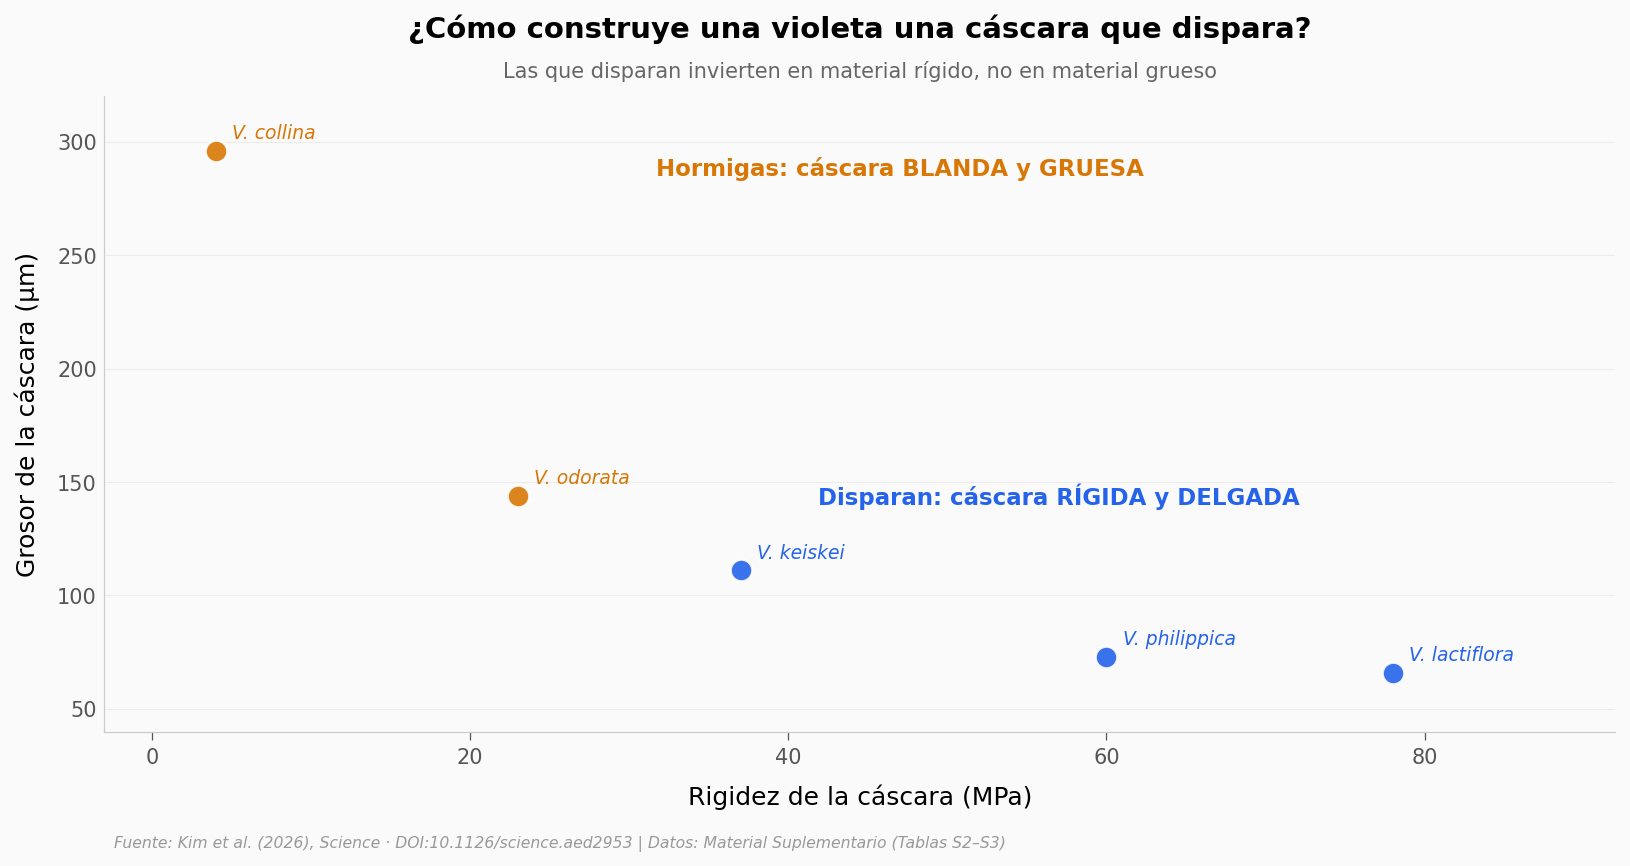

In [2]:
# Mapa de diseño: rigidez de la cáscara vs su grosor
fig, ax = plt.subplots(figsize=(13, 5.5))

for grupo, sub in valvas.groupby('dispersion'):
    ax.scatter(sub.Es_MPa, sub.ts_um, color=COLORES[grupo], s=110, alpha=0.9,
               edgecolors='white', linewidths=1.2, zorder=5)
    for _, r in sub.iterrows():
        ax.annotate(r.especie, (r.Es_MPa, r.ts_um),
                    xytext=(8, 6), textcoords='offset points',
                    fontsize=9, style='italic', color=COLORES[grupo])

# Etiquetas de grupo (inline, reemplazan legend box)
ax.text(57, 140, 'Disparan: cáscara RÍGIDA y DELGADA', fontsize=11,
        fontweight='bold', color=COLOR_BALISTICA, ha='center')
ax.text(47, 285, 'Hormigas: cáscara BLANDA y GRUESA', fontsize=11,
        fontweight='bold', color=COLOR_HORMIGA, ha='center')

ax.set_xlim(-3, 92)
ax.set_ylim(40, 320)
ax.set_xlabel('Rigidez de la cáscara (MPa)')
ax.set_ylabel('Grosor de la cáscara (µm)')
ax.set_title('¿Cómo construye una violeta una cáscara que dispara?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las que disparan invierten en material rígido, no en material grueso',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/mapa_diseno.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que llama la atención

Las violetas que disparan no tienen la cáscara más gruesa — tienen la más **delgada**. Su ventaja no está en poner más material, sino en poner material más **rígido**: la cáscara balística es unas 4 veces más rígida (58 vs 14 MPa) y a la vez un 62 % más fina que la de las que dependen de las hormigas.

Es el principio del paper: lograr fuerza suficiente para el disparo **con poco material**. La forma manda más que la cantidad.

Pero la cáscara es solo una de cinco propiedades que el equipo midió. ¿Cuáles separan de verdad a las dos estrategias?

## ¿Qué propiedad marca la diferencia?

Con solo 3 violetas que disparan y 2 de hormigas, un test de significancia no da para concluir (con esos tamaños, lo mínimo que puede arrojar Mann-Whitney es p = 0,20). Así que no miramos *p-valores*: miramos **qué tan grande es la separación** entre grupos, con el tamaño del efecto (*Cohen's d*).

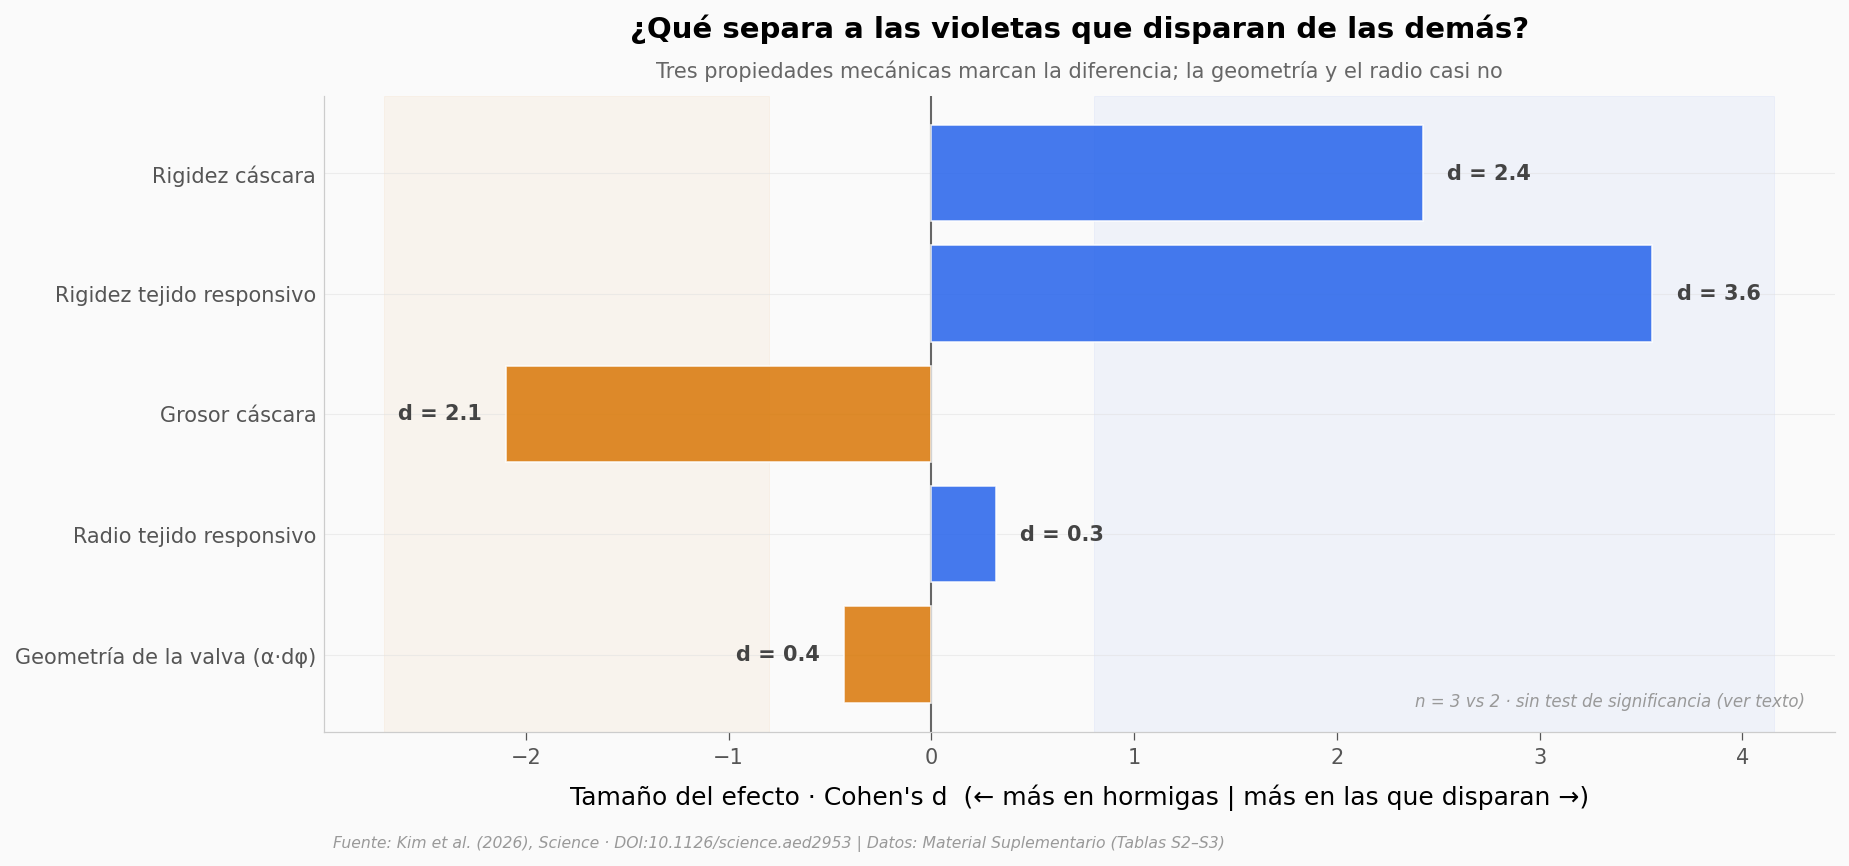

In [3]:
# Tamaño del efecto (Cohen's d) por propiedad — pooled entre grupos
def cohen_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb-1)*b.std(ddof=1)**2) / (na+nb-2))
    return (a.mean() - b.mean()) / s

bal = valvas[valvas.dispersion == 'balistica']
ant = valvas[valvas.dispersion == 'asistida_hormiga']

props = [
    ('Es_MPa', 'Rigidez cáscara'),
    ('Er_MPa', 'Rigidez tejido responsivo'),
    ('ts_um',  'Grosor cáscara'),
    ('Rr_um',  'Radio tejido responsivo'),
    ('alpha_dphi', 'Geometría de la valva (α·dφ)'),
]
nombres = [n for _, n in props]
ds = [cohen_d(bal[c], ant[c]) for c, _ in props]

fig, ax = plt.subplots(figsize=(13, 5.5))
colores_barra = [COLOR_BALISTICA if d > 0 else COLOR_HORMIGA for d in ds]
y = np.arange(len(ds))[::-1]
ax.barh(y, ds, color=colores_barra, alpha=0.85, edgecolor='white', linewidth=0.8, zorder=3)
ax.axvline(0, color='#666666', linewidth=1)
# Banda "efecto grande" (|d| > 0.8)
ax.axvspan(0.8, max(ds)+0.6, color='#2563EB', alpha=0.05, zorder=0)
ax.axvspan(min(ds)-0.6, -0.8, color='#D97706', alpha=0.05, zorder=0)

for yi, (d, n) in zip(y, zip(ds, nombres)):
    ax.text(d + (0.12 if d >= 0 else -0.12), yi, f'd = {abs(d):.1f}',
            va='center', ha='left' if d >= 0 else 'right',
            fontsize=10, fontweight='bold', color='#444444')

ax.set_yticks(y)
ax.set_yticklabels(nombres, fontsize=10)
ax.set_xlabel("Tamaño del efecto · Cohen's d  (← más en hormigas | más en las que disparan →)")
ax.set_xlim(min(ds)-0.9, max(ds)+0.9)
ax.set_title('¿Qué separa a las violetas que disparan de las demás?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tres propiedades mecánicas marcan la diferencia; la geometría y el radio casi no',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.04, 'n = 3 vs 2 · sin test de significancia (ver texto)',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tamanos_efecto.png', dpi=200, bbox_inches='tight')
plt.show()

## Dos materiales que tienen que estar afinados entre sí

La vaina no es una sola pieza. Tiene una **cáscara rígida** (la que da forma y palanca) y un **tejido responsivo** que se hincha o encoge con la humedad y mueve a la cáscara. El pinzamiento sale del juego entre los dos.

Una forma de ver ese afinamiento es la razón entre la rigidez de ambos (cáscara ÷ tejido responsivo).

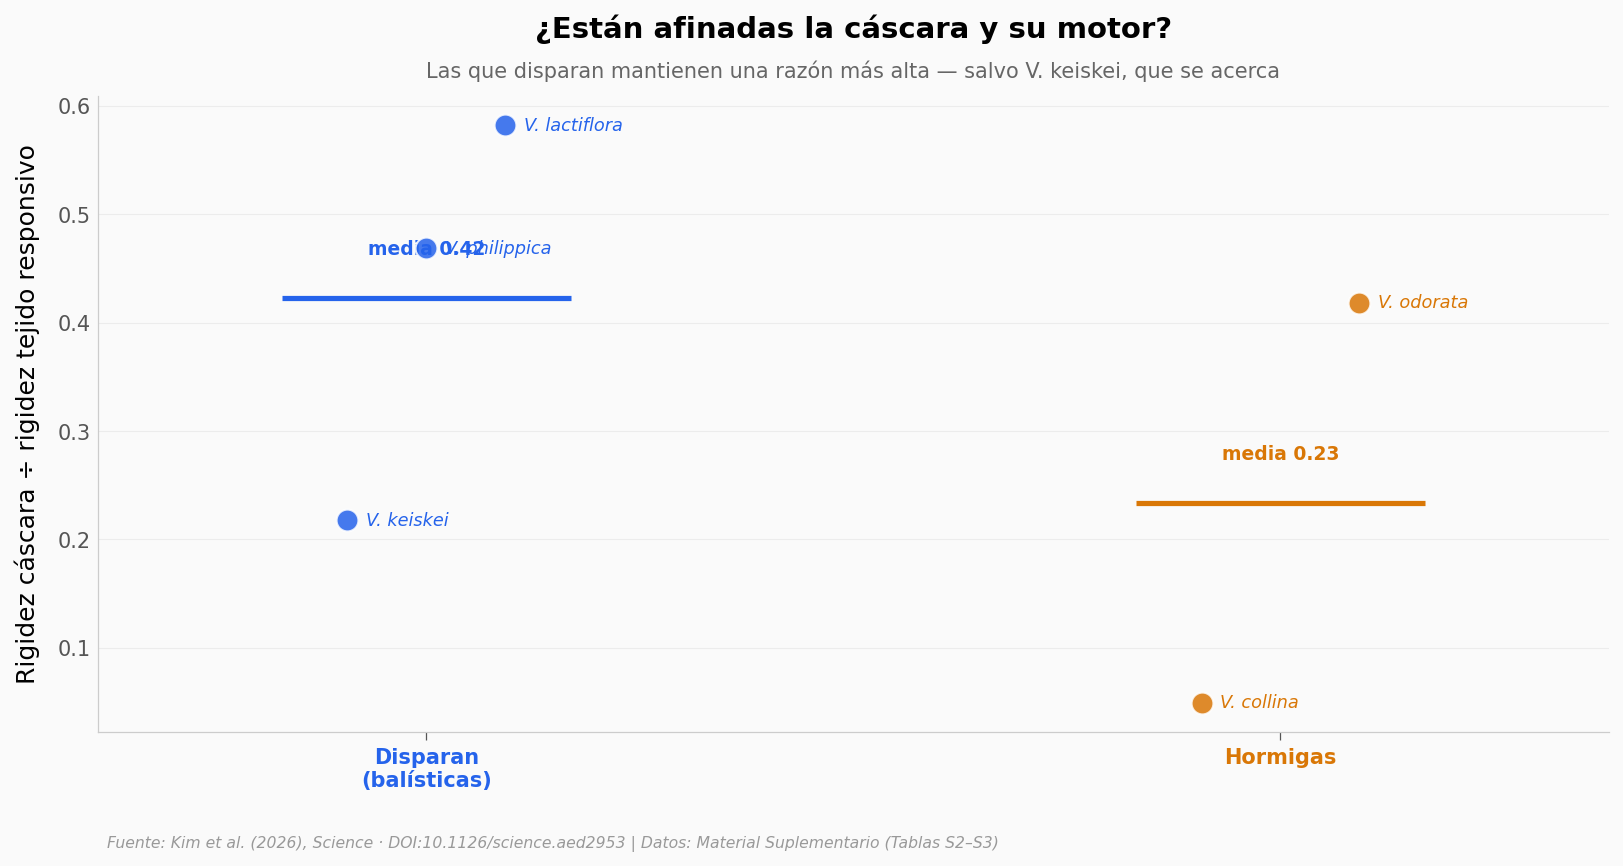

In [4]:
# Razón de rigidez: cáscara / tejido responsivo, por especie
valvas['ratio'] = valvas.Es_MPa / valvas.Er_MPa

np.random.seed(42)
fig, ax = plt.subplots(figsize=(13, 5.5))
posiciones = {'balistica': 0, 'asistida_hormiga': 1.3}
for grupo, sub in valvas.groupby('dispersion'):
    pos = posiciones[grupo]
    n = len(sub)
    x_strip = np.linspace(pos - 0.12, pos + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, sub.ratio, color=COLORES[grupo], s=110, alpha=0.85,
               edgecolors='white', linewidths=1.0, zorder=5)
    for xi, (_, r) in zip(x_strip, sub.iterrows()):
        ax.annotate(r.especie, (xi, r.ratio), xytext=(9, 0),
                    textcoords='offset points', fontsize=8.5,
                    style='italic', color=COLORES[grupo], va='center')
    media = sub.ratio.mean()
    ax.hlines(media, pos - 0.22, pos + 0.22, color=COLORES[grupo],
              linewidth=2.5, zorder=6)
    ax.text(pos, media + 0.04, f'media {media:.2f}', ha='center',
            fontsize=9, fontweight='bold', color=COLORES[grupo])

ax.set_xticks(list(posiciones.values()))
ax.set_xticklabels(['Disparan\n(balísticas)', 'Hormigas'], fontsize=10, fontweight='bold')
for tick, grupo in zip(ax.get_xticklabels(), posiciones):
    tick.set_color(COLORES[grupo])
ax.set_xlim(-0.5, 1.8)
ax.set_ylabel('Rigidez cáscara ÷ rigidez tejido responsivo')
ax.set_title('¿Están afinadas la cáscara y su motor?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las que disparan mantienen una razón más alta — salvo V. keiskei, que se acerca',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/razon_rigidez.png', dpi=200, bbox_inches='tight')
plt.show()

## De la violeta a la máquina

Si el truco está en la **forma** y no en un material exótico, debería funcionar con casi cualquier material. El equipo lo puso a prueba: construyó valvas artificiales que pinzan solas, copiando la geometría de la violeta, con materiales que van desde una resina dura hasta una silicona blanda.

¿Qué tan lejos llega el principio?

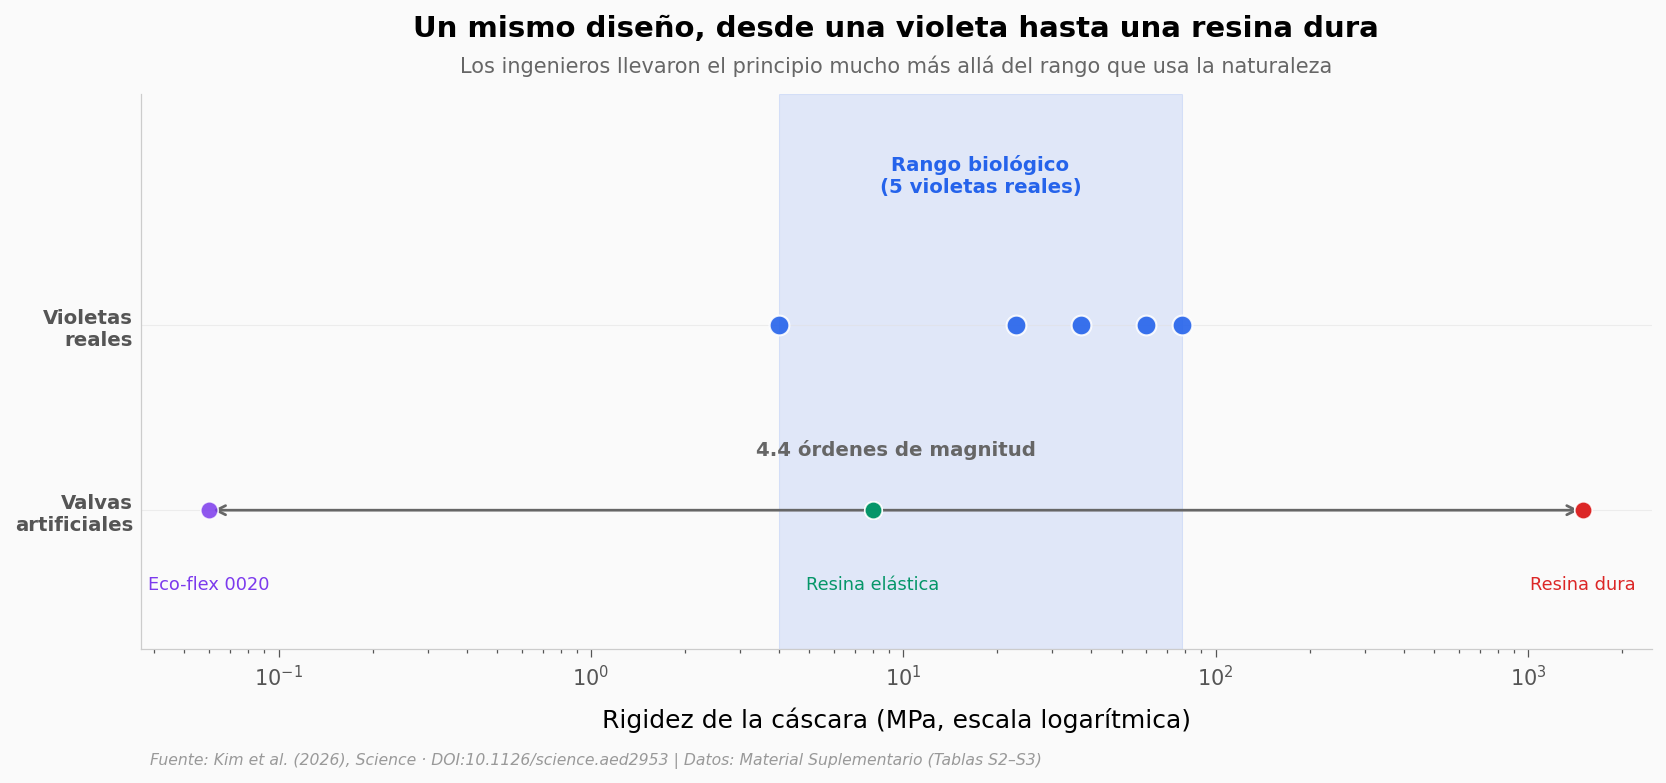

In [5]:
# Cierre: el rango de rigidez que abarca el principio de diseño
fig, ax = plt.subplots(figsize=(13, 4.8))

# Banda biológica (rango de las 5 violetas reales)
bio_min, bio_max = valvas.Es_MPa.min(), valvas.Es_MPa.max()
ax.axvspan(bio_min, bio_max, color=COLOR_BALISTICA, alpha=0.12, zorder=0)
ax.text((bio_min*bio_max)**0.5, 1.28, 'Rango biológico\n(5 violetas reales)',
        ha='center', va='bottom', fontsize=9.5, color=COLOR_BALISTICA, fontweight='bold')

# Violetas reales
ax.scatter(valvas.Es_MPa, np.full(len(valvas), 1.0), color=COLOR_BALISTICA,
           s=90, alpha=0.9, edgecolors='white', linewidths=1.0, zorder=5)
# Valvas artificiales (por material). Las claves vienen en inglés del CSV;
# traducimos solo la ETIQUETA visible (Eco-flex es nombre comercial -> se conserva).
mat_colores = {'Tough resin': COLOR_ALERTA, 'Elastic resin': '#059669', 'Eco-flex 0020': COLOR_REFERENCIA}
MAT_ES = {'Tough resin': 'Resina dura', 'Elastic resin': 'Resina elástica', 'Eco-flex 0020': 'Eco-flex 0020'}
for mat, sub in art.groupby('material'):
    ax.scatter(sub.Es_MPa, np.full(len(sub), 0.6), color=mat_colores[mat],
               s=70, alpha=0.85, edgecolors='white', linewidths=0.8, zorder=5)
    ax.text(sub.Es_MPa.iloc[0], 0.46, MAT_ES[mat], fontsize=8.5, color=mat_colores[mat],
            ha='center', va='top', rotation=0)

# Flecha del rango total artificial
ax.annotate('', xy=(art.Es_MPa.max(), 0.6), xytext=(art.Es_MPa.min(), 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.3))
ordenes = np.log10(art.Es_MPa.max() / art.Es_MPa.min())
ax.text((art.Es_MPa.min()*art.Es_MPa.max())**0.5, 0.72,
        f'{ordenes:.1f} órdenes de magnitud', ha='center', fontsize=9.5,
        color='#666666', fontweight='bold')

ax.set_xscale('log')
ax.set_yticks([0.6, 1.0])
ax.set_yticklabels(['Valvas\nartificiales', 'Violetas\nreales'], fontsize=9.5, fontweight='bold')
ax.set_ylim(0.3, 1.5)
ax.set_xlabel('Rigidez de la cáscara (MPa, escala logarítmica)')
ax.set_title('Un mismo diseño, desde una violeta hasta una resina dura',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.04, 'Los ingenieros llevaron el principio mucho más allá del rango que usa la naturaleza',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espectro_rigidez.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las violetas que disparan tienen la cáscara más rígida | ✅ | 58 vs 14 MPa (+332 %); Cohen's d = 2,4 (efecto grande). Observacional, n = 3 vs 2 |
| …y a la vez más delgada | ✅ | 83 vs 220 µm (−62 %); d = 2,1. El disparo se logra con menos material, no con más |
| El tejido responsivo también es más rígido en las que disparan | ✅ | 144 vs 68 MPa (+112 %); d = 3,6 (el efecto más grande de los cinco) |
| El radio del tejido y la geometría de la valva NO separan a los grupos | ✅ | d = 0,3 y 0,4 — efectos pequeños; no distinguen las estrategias |
| El principio funciona en un rango enorme de materiales | ✅ | Valvas artificiales de 0,06 a 1.500 MPa — 4,4 órdenes de magnitud, con el tejido responsivo fijo |
| La razón cáscara/tejido es más alta en las que disparan | ⚠️ | media 0,42 vs 0,23, pero *V. keiskei* (0,22) se solapa con el grupo de hormigas; tendencia, no corte limpio |

> **Limitaciones:** muestra pequeña (5 especies, 3 vs 2) — los contrastes se sostienen en tamaños de efecto, **no** en significancia estadística (con esos n, p = 0,20 es el mínimo posible). El diseño es **observacional** entre especies: los datos muestran que las que disparan *están construidas* distinto, no que disparar *cause* esa construcción. Las propiedades vienen del Material Suplementario (Tablas S2–S3); el repositorio Dryad estaba bajo curación al consultar.

## Ahora tú

1. **¿Y si miras rigidez contra grosor como una sola variable?** Prueba calcular un índice de "rigidez por unidad de grosor" (`valvas.Es_MPa / valvas.ts_um`) y ordena las especies. ¿Las que disparan quedan arriba?
2. **¿Cuánto pesa _V. collina_ en los promedios?** Es la más blanda y gruesa de todas. Recalcula las medias de cada grupo sacándola (`valvas.drop(...)`). ¿Cambia la historia?
3. **¿Dónde caen las valvas artificiales en el mapa de diseño?** Lleva la tabla `art` al gráfico de rigidez vs grosor de la celda 4. ¿Cubren el rango biológico o lo desbordan?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: rigidez por unidad de grosor — ¿quién aprovecha mejor el material?
valvas['rigidez_por_grosor'] = valvas.Es_MPa / valvas.ts_um  # MPa por µm

ranking = valvas.sort_values('rigidez_por_grosor', ascending=False)
print('Rigidez por unidad de grosor (MPa/µm) — de mayor a menor:')
for _, r in ranking.iterrows():
    marca = '🎯' if r.dispersion == 'balistica' else '🐜'
    print(f'  {marca} {r.especie:16s} {r.rigidez_por_grosor:.3f}  ({GRUPOS[r.dispersion]})')

print('\nMedia por grupo:')
for grupo, sub in valvas.groupby('dispersion'):
    print(f'  {GRUPOS[grupo]:22s} {sub.rigidez_por_grosor.mean():.3f} MPa/µm')

Rigidez por unidad de grosor (MPa/µm) — de mayor a menor:
  🎯 V. lactiflora    1.182  (Disparan (balísticas))
  🎯 V. philippica    0.822  (Disparan (balísticas))
  🎯 V. keiskei       0.333  (Disparan (balísticas))
  🐜 V. odorata       0.160  (Hormigas)
  🐜 V. collina       0.014  (Hormigas)

Media por grupo:
  Hormigas               0.087 MPa/µm
  Disparan (balísticas)  0.779 MPa/µm


## Fuentes

**Paper**: [Viola seed pod architecture shapes sequential, force-augmented pinching](https://doi.org/10.1126/science.aed2953)  
*Science, 2026-06-18 · paywall*

**Material Suplementario**: [Tablas S1–S3](https://www.science.org/doi/suppl/10.1126/science.aed2953/suppl_file/science.aed2953_sm.pdf)  
*Propiedades mecánicas de 5 especies y de las valvas artificiales*

**Repositorio de datos**: [Dryad](https://doi.org/10.5061/dryad.pc866t246) *(bajo curación al consultar)*

*11 afirmaciones del notebook verificadas contra estas fuentes*